# Physics-Informed Variational Autoencoder for Optical Glass Latent Space

## Introduction and Motivation
In classical optical design, material selection is a discrete, combinatorial optimization problem. An optical designer must choose from discrete catalogs of commercial glasses (e.g., Schott, Ohara), which limits the ability of continuous, gradient-based optimization algorithms to explore the material space efficiently.

A Variational Autoencoder (VAE) provides a compelling solution: by mapping the discrete set of available optical glasses into a continuous, low-dimensional, and differentiable latent space, we can transform combinatorial glass selection into a continuous optimization problem. Gradient-descent algorithms can then backpropagate through the VAE's decoder to optimize the glass choice natively. The model generates physically plausible dispersion curves from latent vectors, enabling continuous material optimization in lens design.

**What is a VAE?**
For those new to deep learning, a standard Autoencoder compresses data into a small vector (via Encoder) and reconstructs it (via Decoder). A *Variational* Autoencoder adds a statistical twist: instead of compressing a glass into a single fixed point, it compresses it into a probability distribution (a mean and variance). This forces the network to learn a smooth, continuous "latent space" where every point maps to a valid, sensible output, making it ideal for continuous optimization and generating new materials.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading and Normalization

We load the glass refractive indices dataset, containing $N=128$ uniformly spaced wavelengths between 0.380 µm and 0.780 µm. This dataset was generated using `1_generate_vae_dataset.ipynb` in the same directory.

**Normalization Strategy:**
Neural networks train best when inputs are centered around zero with a standard deviation of one. 
- **Inputs to Encoder:** We normalize the 128-dimensional curves so the encoder can easily process them.
- **Targets for Loss:** Our custom physics decoder will output raw, physical refractive indices. Therefore, we will evaluate our loss function against the *unnormalized, physical* data.

In [2]:
class GlassDataset(Dataset):
    def __init__(self, npy_file):
        # Load the raw physical data
        self.data_physical = np.load(npy_file)
        
        # Calculate global normalization statistics for the encoder input
        self.mean = np.mean(self.data_physical)
        self.std = np.std(self.data_physical)
        
        # Normalize the data for the encoder
        self.data_normalized = (self.data_physical - self.mean) / self.std
        
        # Convert to torch tensors
        self.data_normalized = torch.tensor(self.data_normalized, dtype=torch.float32)
        self.data_physical = torch.tensor(self.data_physical, dtype=torch.float32)

    def __len__(self):
        return len(self.data_physical)

    def __getitem__(self, idx):
        # Return both the normalized input (for the encoder) and the physical target (for the loss)
        return self.data_normalized[idx], self.data_physical[idx]


# Initialize dataset and dataloader
dataset = GlassDataset('glasses_refractive_indices.npy')
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Loaded {len(dataset)} glasses.")
print(f"Global mean: {dataset.mean:.4f}, Global std: {dataset.std:.4f}")

Loaded 1678 glasses.
Global mean: 1.6935, Global std: 0.1301


## 2. Model Architecture: The Buchdahl Decoder

A naive VAE might output a curve with random, unphysical spikes because it treats each wavelength independently. To guarantee physically valid glasses, we bake optical physics directly into the network. This makes our network a Physics-Informed Neural Network (PINN).

Instead of outputting 128 independent points, the Decoder outputs a few coefficients of the **Buchdahl dispersion model**. The Buchdahl model accurately calculates refractive index using a continuous chromatic coordinate $w$:
$$w = \frac{\lambda - \lambda_d}{1 + 2.5(\lambda - \lambda_d)}$$
Where $\lambda_d = 0.5875618 \mu m$ (the helium d-line). The refractive index is a simple polynomial:
$$n(\lambda) = n_d + \sum_{i=1}^{k-1} c_i w^i$$

**Architecture Flow:**
1. **Encoder:** Maps the input curve to a small, 4-dimensional latent vector $z$.
2. **Decoder MLP:** Maps $z$ to a small vector of $k$ physical coefficients: $[n_d, c_1, c_2, ...]$.
3. **Buchdahl Layer (Deterministic):** Converts those coefficients back into the 128-point curve using the formula above. This mathematically guarantees the generated curves are smooth and exhibit valid dispersion.

In [3]:
class BuchdahlGlassVAE(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, latent_dim=4, num_buchdahl_coeffs=4):
        super(BuchdahlGlassVAE, self).__init__()
        
        self.num_coeffs = num_buchdahl_coeffs
        
        # --- Precompute Buchdahl Wavelength Grid ---
        # Wavelengths in microns
        L = torch.linspace(0.380, 0.780, input_dim)
        L_d = 0.5875618
        
        # Calculate the Buchdahl chromatic coordinate 'w'
        w = (L - L_d) / (1.0 + 2.5 * (L - L_d))
        
        # Precompute powers of w for efficient matrix multiplication
        w_powers = torch.stack([w**i for i in range(1, self.num_coeffs)])
        
        # Register as buffer so it moves to GPU automatically
        self.register_buffer('w_powers', w_powers)
        
        # --- Encoder ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.SiLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU() 
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # --- Decoder ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.SiLU(),
            nn.Linear(hidden_dim * 2, self.num_coeffs) 
        )
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def decode_to_curve(self, z):
        # 1. Predict Buchdahl coefficients
        coeffs = self.decoder(z) # Shape: (batch, num_coeffs)
        
        # 2. Extract n_d and the higher-order coefficients
        n_d = coeffs[:, 0].unsqueeze(1) # Shape: (batch, 1)
        c = coeffs[:, 1:]               # Shape: (batch, num_coeffs - 1)
        
        # 3. Deterministically compute the dispersion curve
        dispersion = torch.matmul(c, self.w_powers) 
        n_lambda = n_d + dispersion
        return n_lambda
        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon_physical = self.decode_to_curve(z)
        return x_recon_physical, mu, logvar


# Initialize the model
input_dim = dataset.data_physical.shape[1]
latent_dim = 4
num_coeffs = 4  # Configurable: n_d + 3 polynomial terms

model = BuchdahlGlassVAE(
    input_dim=input_dim, 
    hidden_dim=64, 
    latent_dim=latent_dim, 
    num_buchdahl_coeffs=num_coeffs
).to(device)

## 3. Loss Function

Because our Buchdahl decoder guarantees smooth dispersion curves, our loss function is incredibly simple. It consists of two standard VAE terms:

1. **Reconstruction Loss (MSE):** Measures how closely the decoded physical curve matches the original physical curve.
2. **KL Divergence:** A mathematical penalty that forces the latent space to organize itself neatly into a standard bell curve (normal distribution). This neat organization is what allows us to sample new glasses smoothly later.

*Note: We multiply the MSE by a scaling factor to keep its magnitude comparable to the KL term.*

In [4]:
def vae_loss(x_recon_physical, x_target_physical, mu, logvar, beta=1.0):
    # 1. Reconstruction Loss (Physical scale MSE)
    recon_loss = nn.functional.mse_loss(x_recon_physical, x_target_physical, reduction='mean') * 1000.0
    
    # 2. KL Divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

## 4. Training Setup & KL Annealing

**The Problem of Posterior Collapse:**
The KL Divergence penalty acts like a rubber band, pulling all latent points toward the center $(0,0,0,0)$. If this penalty is too strong early in training, the network gives up on learning individual glasses and just outputs the "average" glass for everything. This is called *posterior collapse*. If this happens, generated synthetic glasses will cluster in the center of the Abbe diagram and fail to span the edges (like extreme Flint or Crown glasses).

**The Solution: KL Annealing**
We use a parameter called `beta` ($\beta$) to control the strength of the KL penalty. We start training with $\beta = 0$ (no rubber band), allowing the network to focus entirely on perfectly reconstructing the extreme edges of the glass map. Over the first several hundred epochs, we linearly increase $\beta$ to our target value, gently organizing the space without collapsing it.

In [5]:
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

num_epochs = 1500
target_beta = 0.005
warmup_epochs = 600  # Duration to slowly increase beta

def get_beta(epoch, warmup_epochs, target_beta):
    if epoch >= warmup_epochs:
        return target_beta
    return target_beta * (epoch / warmup_epochs)

for epoch in range(num_epochs):
    model.train()
    total_loss_epoch, recon_loss_epoch, kl_loss_epoch = 0, 0, 0
    
    # Calculate current beta for KL Annealing
    current_beta = get_beta(epoch, warmup_epochs, target_beta)
    
    for batch_normalized, batch_physical in dataloader:
        batch_normalized = batch_normalized.to(device)
        batch_physical = batch_physical.to(device)
        
        optimizer.zero_grad()
        
        x_recon_physical, mu, logvar = model(batch_normalized)
        loss, recon, kl = vae_loss(x_recon_physical, batch_physical, mu, logvar, beta=current_beta)
        
        loss.backward()
        optimizer.step()
        
        total_loss_epoch += loss.item()
        recon_loss_epoch += recon.item()
        kl_loss_epoch += kl.item()
        
    scheduler.step()
        
    # Print metrics periodically
    if (epoch + 1) % 150 == 0 or epoch == 0:
        n_batches = len(dataloader)
        print(f"Epoch [{epoch+1:4d}/{num_epochs}] "
              f"Beta: {current_beta:.4f} | "
              f"Loss: {total_loss_epoch/n_batches:.4f} | "
              f"Recon: {recon_loss_epoch/n_batches:.4f} | "
              f"KL: {kl_loss_epoch/n_batches:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.1e}")

Epoch [   1/1500] Beta: 0.0000 | Loss: 629.5663 | Recon: 629.5663 | KL: 0.6605 | LR: 2.0e-03
Epoch [ 150/1500] Beta: 0.0012 | Loss: 0.0784 | Recon: 0.0713 | KL: 5.7278 | LR: 2.0e-03
Epoch [ 300/1500] Beta: 0.0025 | Loss: 0.0125 | Recon: 0.0047 | KL: 3.1458 | LR: 2.0e-03
Epoch [ 450/1500] Beta: 0.0037 | Loss: 0.0124 | Recon: 0.0030 | KL: 2.5260 | LR: 2.0e-03
Epoch [ 600/1500] Beta: 0.0050 | Loss: 0.0128 | Recon: 0.0025 | KL: 2.0534 | LR: 1.0e-03
Epoch [ 750/1500] Beta: 0.0050 | Loss: 0.0150 | Recon: 0.0064 | KL: 1.7196 | LR: 1.0e-03
Epoch [ 900/1500] Beta: 0.0050 | Loss: 0.0114 | Recon: 0.0035 | KL: 1.5923 | LR: 1.0e-03
Epoch [1050/1500] Beta: 0.0050 | Loss: 0.0105 | Recon: 0.0026 | KL: 1.5757 | LR: 5.0e-04
Epoch [1200/1500] Beta: 0.0050 | Loss: 0.0101 | Recon: 0.0022 | KL: 1.5764 | LR: 5.0e-04
Epoch [1350/1500] Beta: 0.0050 | Loss: 0.0117 | Recon: 0.0038 | KL: 1.5688 | LR: 5.0e-04
Epoch [1500/1500] Beta: 0.0050 | Loss: 0.0106 | Recon: 0.0027 | KL: 1.5853 | LR: 2.5e-04


In [6]:
# Save torch model weights
torch.save(model.state_dict(), 'PINN_VAE_weights.pth')

## 5. Sampling & Visualization (The Glass Map)

With the VAE trained, we can unconditionally sample novel optical glasses from the standard normal prior $\mathcal{N}(0, I)$. 

Because of our custom Buchdahl decoder layer, the network natively outputs mathematically valid refractive index curves directly on the physical scale. We extract $n_d, n_F,$ and $n_C$ to calculate the Abbe number ($V_d$) and project the continuous generated materials onto the classical Abbe diagram.

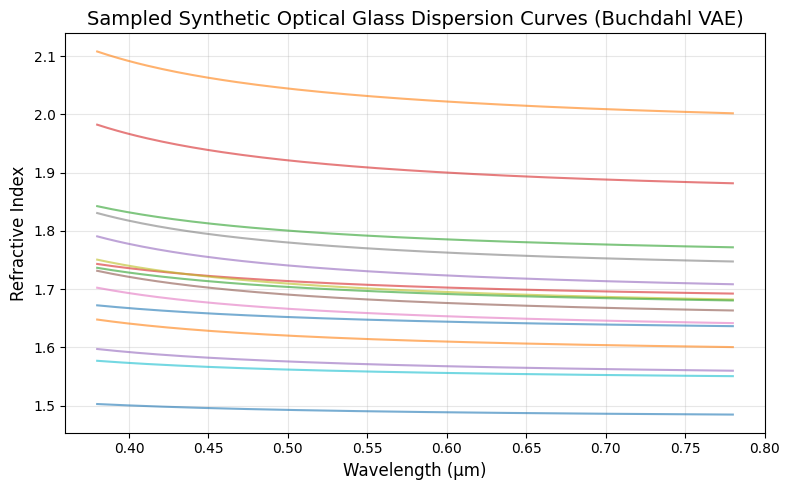

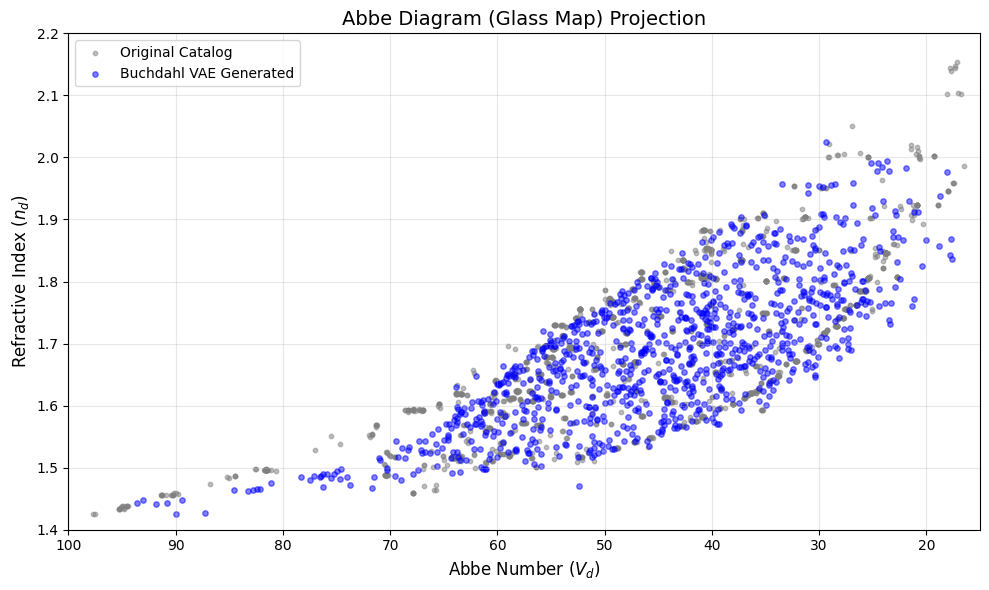

In [7]:
# Spectral Grid parameters corresponding to the dataset
WAVE_GRID = np.linspace(0.380, 0.780, 128)
WAVE_D = 0.5875618  
WAVE_F = 0.4861327  
WAVE_C = 0.6562725  

def interpolate_index(curves, w, grid=WAVE_GRID):
    """1D linear interpolation to extract the index at wavelength `w`."""
    idx = (w - grid[0]) / (grid[-1] - grid[0]) * (len(grid) - 1)
    idx_lower = int(np.floor(idx))
    idx_upper = int(np.ceil(idx))
    weight = idx - idx_lower
    
    val_lower = curves[:, idx_lower]
    val_upper = curves[:, idx_upper]
    return val_lower * (1 - weight) + val_upper * weight

model.eval()

# 1. Generate new index curves from the latent space
num_samples = 1000
with torch.no_grad():
    z_samples = torch.randn(num_samples, latent_dim).to(device)
    generated_curves_physical = model.decode_to_curve(z_samples).cpu()

# 2. Plot a subset of generated dispersion curves
plt.figure(figsize=(8, 5))
for i in range(15):
    plt.plot(WAVE_GRID, generated_curves_physical[i].numpy(), alpha=0.6)
plt.title("Sampled Synthetic Optical Glass Dispersion Curves (Buchdahl VAE)", fontsize=14)
plt.xlabel("Wavelength (\u00b5m)", fontsize=12)
plt.ylabel("Refractive Index", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Project both original and generated data onto the Abbe Diagram
def calculate_abbe_from_curves(curves):
    nd = interpolate_index(curves, WAVE_D, WAVE_GRID)
    nF = interpolate_index(curves, WAVE_F, WAVE_GRID)
    nC = interpolate_index(curves, WAVE_C, WAVE_GRID)
    Vd = (nd - 1) / (nF - nC)
    return nd, Vd

orig_nd, orig_Vd = calculate_abbe_from_curves(dataset.data_physical)
gen_nd, gen_Vd = calculate_abbe_from_curves(generated_curves_physical)

plt.figure(figsize=(10, 6))
plt.scatter(orig_Vd.numpy(), orig_nd.numpy(), s=10, c='gray', alpha=0.5, label='Original Catalog')
plt.scatter(gen_Vd.numpy(), gen_nd.numpy(), s=15, c='blue', alpha=0.5, label='Buchdahl VAE Generated')

# Format Abbe Diagram (Vd is traditionally plotted descending)
plt.xlim(100, 15) 
plt.ylim(1.4, 2.2)
plt.title("Abbe Diagram (Glass Map) Projection", fontsize=14)
plt.xlabel("Abbe Number ($V_d$)", fontsize=12)
plt.ylabel("Refractive Index ($n_d$)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Clearly, we can see that our VAE generates realistic glasses that fall cleanly within the bounds of the glass map. The dispersion curves show typical behavior over the visible spectrum, largely as a result of the physical constraint applied via the use of the Buchdahl model.

## 6. Conclusion and Next Steps

By embedding the Buchdahl dispersion model directly into a Variational Autoencoder, we created a physics-informed network that natively generates valid, continuous optical materials. 

**Key Takeaways:**
*   **Physics by Architecture:** Replacing complex, unstable loss penalties with a deterministic formula layer guarantees structural validity while maintaining perfect gradient flow.
*   **Latent Space Mapping:** We have compressed the discrete, rigid catalog into a mathematically robust 4-dimensional continuous space that fully spans the classical 2D Abbe map.

**Why This Matters:**
Traditional optical design treats material selection as an inefficient combinatorial problem. Legacy optimizers are forced to "guess and check" discrete catalog glasses, which breaks continuous gradient flow and scales poorly for complex lens systems. This architecture solves that bottleneck elegantly. By transforming the discrete catalog into a smooth, differentiable topography, we unlock the full power of modern deep learning optimizers. A raytracer can now mathematically "slide" a lens element's material across the glass map, calculating exact gradients for chromatic aberration and spot size, drastically reducing the computational time required to find an optimal lens prescription.

**Next Steps (Integration into Optiland):**
This model is designed to act as the material engine for a differentiable raytracing software. In Optiland:
1.  The VAE Encoder is discarded; only the pre-trained, frozen Decoder is loaded.
2.  Discrete glass variables on lens elements are replaced by learnable 4D latent vectors ($z_{lens}$).
3.  During optimization (e.g., via L-BFGS or Adam), gradients flow backward from the focal plane error, through the ray intersections, through the frozen Decoder, and directly update $z_{lens}$.
4.  Upon convergence, the optimized continuous $z_{lens}$ coordinate is "snapped" to the nearest neighbor in the real-world catalog for physical manufacturing.